## This notebook can be used to rank a list of nodes from a category that connect to an entity such as a gene. 

In [1]:
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT


### Load Translator resources


In [2]:
APInames, metaKG, Translator_KP_info = translator_metakg.load_translator_resources()

In [3]:
All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

## Find the neighborhood of an entity from a subset of APIs 


In [4]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
print(select_APIs)
print(selected_metaKG.shape)


{'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Genetics Data Provider for NCATS Biomedical Translator Reasoners': 'https://genetics-kp.transltr.io/genetics_provider/trapi/v1.5/query/', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'Text Mined Cooccurrence API': 'https://cooccurrence.transltr.io/query/', 'BioThings Explorer (BTE) TRAPI': 'https://bte.transltr.io/v1/query/', 'Gene-List Network Enrichment Analysis': 'https://translator.broadinstitute.org/gelinea-trapi/v1.5/query/', 'MolePro': 'https://molepro-trapi.transltr.io/molepro/trapi/v1.5/query/', 'COHD TRAPI': 'https://cohd-api.transltr.io/api/query/', 'Multiomics KP - TRAPI

In order to use the neighborhood finder, we have to look up a CURIE ID for a given term.

In [12]:
name_resolver.lookup('Acute myeloid leukemia')
name_resolver.lookup('AML', return_top_response=False, biolink_type='biolink:Disease', limit=10) # sometimes the identifiers are not in the top 1, users need to check the other returned results

[TranslatorNode(curie='MONDO:0042982', label='GATA2 deficiency with susceptibility to MDS/AML', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity'], synonyms=None, curie_synonyms=None),
 TranslatorNode(curie='UMLS:C2861614', label='AML M5b', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity'], synonyms=None, curie_synonyms=None),
 TranslatorNode(curie='MONDO:0018874', label='acute myeloid leukemia', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity'], synonyms=None, curie_synonyms=None),
 TranslatorNode(curie='UMLS:C5225814', label='Leukemia - acute myeloid leukemia (AML)', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:

The CURIE ID for acute myeloid leukemia is `MONDO:0018874`. We will use this CURIE ID for subsequent tasks.

Neighborhood finder identifies all nodes *b* that are connected to the given node *a*, where *b* is part of a defined list of categories - returning the neighborhood of node *a*.

In [13]:
input_node_id, result, result_parsed, result_ranked_by_primary_infores = TCT.Neiborhood_finder('MONDO:0018874',
                                                                                            node2_categories = ['biolink:SmallMolecule', 'biolink:Drug', 'biolink:ChemicalEntity'],
                                                                                            APInames = select_APIs,
                                                                                            metaKG = selected_metaKG,
                                                                                            API_predicates = API_predicates)     

MONDO:0018874
Automat-hetionet(Trapi v1.5.0): Success!
Automat-monarchinitiative(Trapi v1.5.0): Success!
Automat-ctd(Trapi v1.5.0): Success!
Drug Approvals KP - TRAPI 1.5.0: Success!
Automat-drug-central(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Text Mined Cooccurrence API: Success!
Automat-robokop(Trapi v1.5.0): Success!
Clinical Trials KP - TRAPI 1.5.0: Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
NodeNorm does not know about these identifiers: DRUGBANK:DB15060,REACT:R-ALL-9692345,DRUGBANK:DB04945,DRUGBANK:DB19304,DRUGBANK:DB16471,UMLS:C5966113,UMLS:C5907983,UMLS:C5908001,UMLS:C5959689,UMLS:C5960828,DRUGBANK:DB19070,GTOPDB:13607,UMLS:C5907931,CHEBI:233197,UMLS:C5888788,UMLS:C5961048,CHEBI:233593,UMLS:C5979854,UMLS:C5907992,CHEBI:232584,DRUGBANK:DB18980,CHEBI:232328,CHEBI:233359,UMLS:DC0003818,UMLS:DC0012155,UMLS:DC0037549,UMLS:DC0041411,MESH:C059764,MESH:D000596,MESH:C081693,UMLS:C0596087,UMLS:C0002073,UNII:7EV65EAW6H,UMLS:C0062128,

NodeNorm does not know about these identifiers: UNII:7EV65EAW6H,UMLS:DC0003818,UMLS:DC0012155,UNII:IZR558KO53,UNII:E6349B696W,UNII:FR89SC8CT4,UNII:PVH8394DLN,UNII:O5V0F26RUW,UNII:Y8DGL9885E,UNII:ET4JC4S66E,GTOPDB:13607,CHEBI:233197,UMLS:C5907931,UMLS:C5907983,UMLS:C5966113,DRUGBANK:DB16471,DRUGBANK:DB19070,DRUGBANK:DB19304,UMLS:C5960828,UMLS:C5959689,UMLS:C5908001,UMLS:C0597573,UMLS:C0596087,UMLS:C0002073,UMLS:C0062128,UNII:Q805XO2F7C,UNII:VS12X225PL,UNII:475247QF1Z,UNII:L4D9X59F34,UNII:RXG7T6RB8K,RXCUI:1791496,RXCUI:1736582,RXCUI:1722942,UNII:3D2KVS9K7P,UNII:OEN4982XNW,RXCUI:1362054,RXCUI:1723777,RXCUI:379454,RXCUI:1860464,RXCUI:1658260,RXCUI:1795608,RXCUI:1666799,RXCUI:1729198,RXCUI:1360104,RXCUI:1719287,RXCUI:900963,RXCUI:1656667,RXCUI:1362049,RXCUI:1665191,RXCUI:1433769,RXCUI:1795154,RXCUI:1662281,RXCUI:1362058,RXCUI:1860240,RXCUI:1807509,DRUGBANK:DB18980,UMLS:C5979854,UMLS:C5907992,CHEBI:232584,UMLS:DC0037549,UMLS:DC0041411,CHEBI:232328,CHEBI:233359,UMLS:C5888788,CHEBI:233593,UMLS

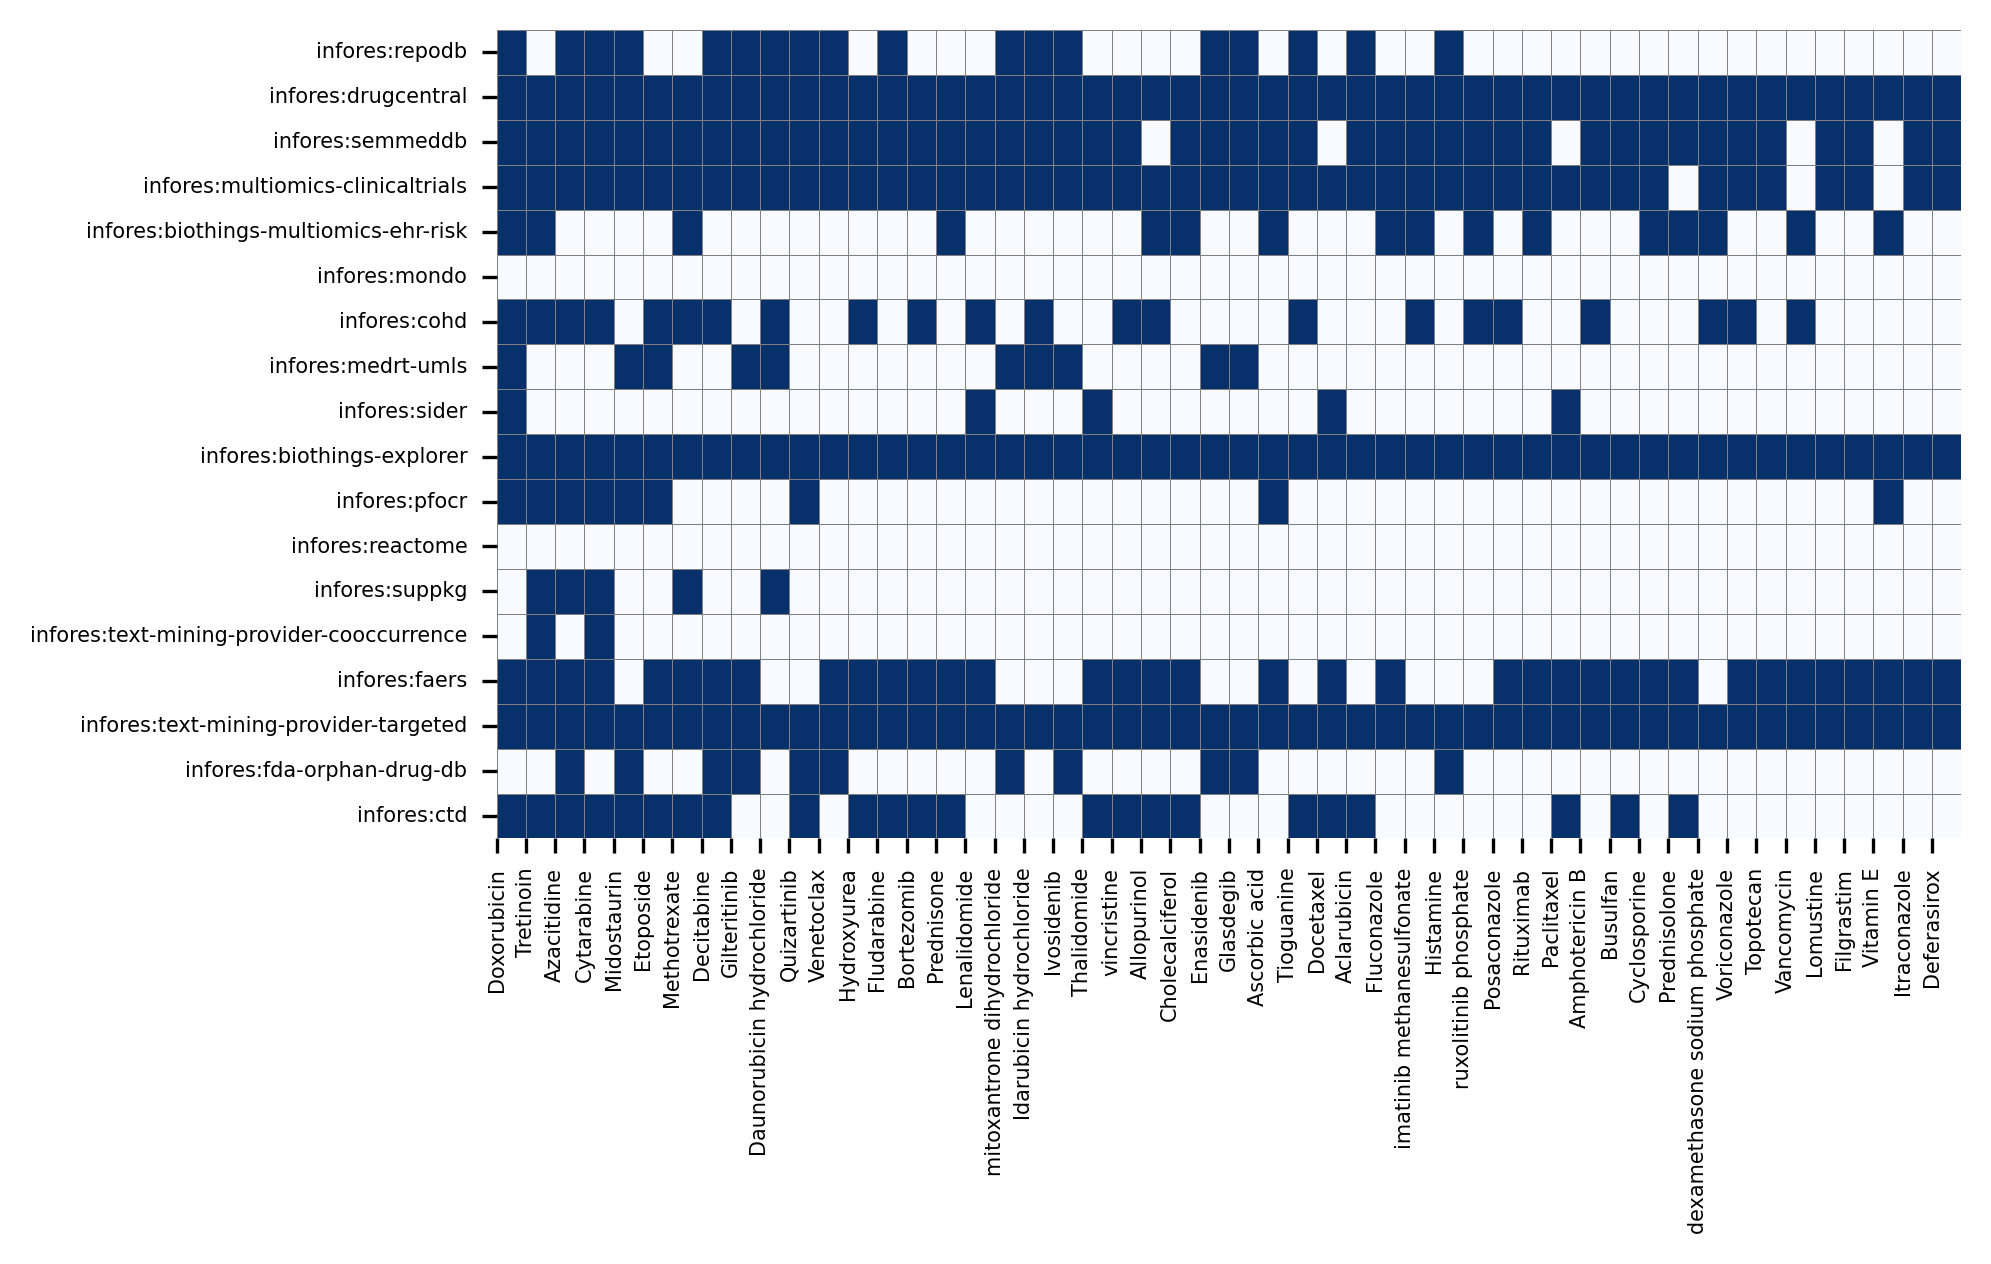

[Text(0.5, 0, 'Doxorubicin'), Text(2.5, 0, 'Azacitidine'), Text(4.5, 0, 'Midostaurin'), Text(6.5, 0, 'Methotrexate'), Text(8.5, 0, 'Gilteritinib'), Text(10.5, 0, 'Quizartinib'), Text(12.5, 0, 'Hydroxyurea'), Text(14.5, 0, 'Bortezomib'), Text(16.5, 0, 'Lenalidomide'), Text(18.5, 0, 'Idarubicin hydrochloride'), Text(20.5, 0, 'Thalidomide'), Text(22.5, 0, 'Allopurinol'), Text(24.5, 0, 'Enasidenib'), Text(26.5, 0, 'Ascorbic acid'), Text(28.5, 0, 'Docetaxel'), Text(30.5, 0, 'Fluconazole'), Text(32.5, 0, 'Histamine'), Text(34.5, 0, 'Posaconazole'), Text(36.5, 0, 'Paclitaxel'), Text(38.5, 0, 'Busulfan'), Text(40.5, 0, 'Prednisolone'), Text(42.5, 0, 'Voriconazole'), Text(44.5, 0, 'Vancomycin'), Text(46.5, 0, 'Filgrastim'), Text(48.5, 0, 'Itraconazole')]


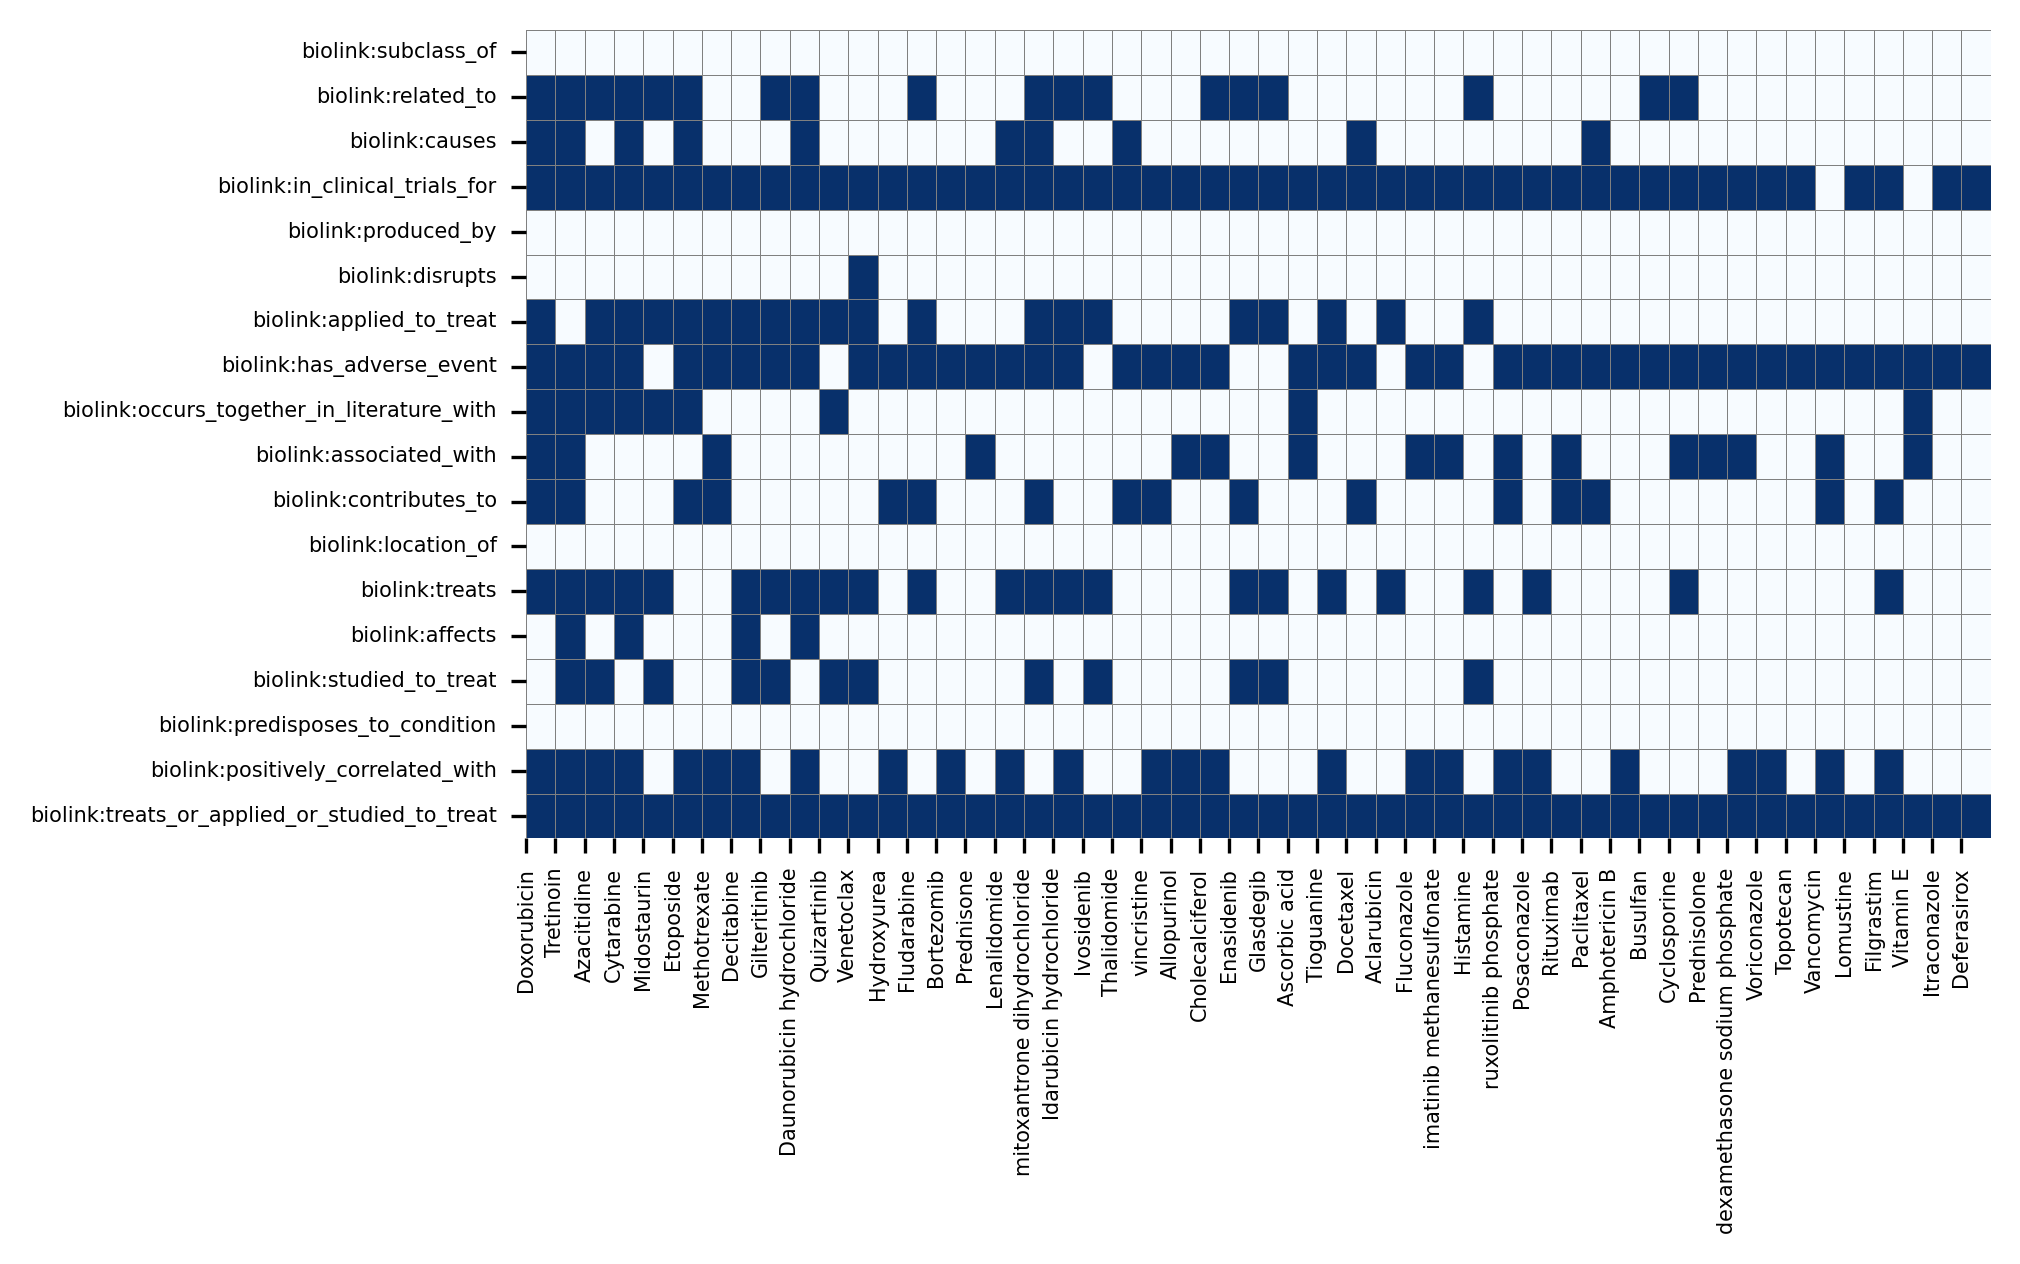

,Doxorubicin,Tretinoin,Azacitidine,Cytarabine,Midostaurin,Etoposide,Methotrexate,Decitabine,Gilteritinib,Daunorubicin hydrochloride,...,Topotecan,Chloroquine,Posaconazole,Citicoline,octan-1-ol,Estramustine,Ethionamide,BMS-214662,Vindesine,CEDIRANIB MALEATE
biolink:subclass_of,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:related_to,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:causes,1,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
biolink:in_clinical_trials_for,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1
biolink:produced_by,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:disrupts,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:applied_to_treat,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:has_adverse_event,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:occurs_together_in_literature_with,1,1,1,1,1,1,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
biolink:associated_with,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores, result_parsed, 
                                num_of_nodes = 50, input_query = input_node_id, 
                                fontsize = 5)

In [15]:
result_ranked_by_primary_infores

,output_node,Name,Num_of_primary_infores,type_of_nodes,unique_predicates
21,CHEBI:28748,Doxorubicin,13,subject,[biolink:treats_or_applied_or_studied_to_treat...
256,CHEBI:15367,Tretinoin,12,subject,"[biolink:affects, biolink:related_to, biolink:..."
29,CHEBI:2038,Azacitidine,12,subject,[biolink:treats_or_applied_or_studied_to_treat...
23,CHEBI:28680,Cytarabine,12,subject,[biolink:treats_or_applied_or_studied_to_treat...
242,CHEBI:63452,Midostaurin,10,subject,"[biolink:related_to, biolink:applied_to_treat,..."
...,...,...,...,...,...
1440,DRUGBANK:DB01196,Estramustine,1,subject,[biolink:occurs_together_in_literature_with]
1441,DRUGBANK:DB00609,Ethionamide,1,subject,[biolink:occurs_together_in_literature_with]
1442,DRUGBANK:DB12234,BMS-214662,1,subject,[biolink:occurs_together_in_literature_with]
1443,DRUGBANK:DB00309,Vindesine,1,subject,[biolink:occurs_together_in_literature_with]


In [17]:
from TCT import TCT_Visualization

dic_graph = TCT_Visualization.visualize_neighborhood_graph(result, show_label=True, height="500", width="100%")

NodeNorm does not know about these identifiers: UNII:7EV65EAW6H,CHEBI:232328,UNII:E6349B696W,RXCUI:1736582,UMLS:DC0003818,UMLS:C0596087,CHEBI:233197,UNII:IZR558KO53,DRUGBANK:DB18772,RXCUI:1658260,RXCUI:1722942,UMLS:C0062128,DRUGBANK:DB15060,UMLS:C5907983,UNII:OEN4982XNW,RXCUI:1362049,RXCUI:900963,RXCUI:1795154,UMLS:C5908001,CHEBI:233362,RXCUI:1362058,DRUGBANK:DB18980,RXCUI:1719287,UNII:475247QF1Z,MESH:D000596,RXCUI:1729198,RXCUI:1656667,UMLS:C5888788,UNII:ET4JC4S66E,UNII:VS12X225PL,CHEBI:233593,UMLS:C5960828,UNII:FR89SC8CT4,RXCUI:1860464,UNII:O5V0F26RUW,CHEBI:232584,UNII:3D2KVS9K7P,RXCUI:379454,DRUGBANK:DB16471,UMLS:C5966113,UMLS:C0597573,DRUGBANK:DB19304,UMLS:C5907992,RXCUI:1362054,RXCUI:1433769,UNII:L4D9X59F34,RXCUI:1666799,RXCUI:1662281,MESH:C059764,DRUGBANK:DB04945,REACT:R-ALL-9692345,MESH:C081693,UMLS:C5907931,UNII:PVH8394DLN,UNII:241ATL177A,UNII:Q805XO2F7C,UMLS:C0002073,CHEBI:233318,RXCUI:1791496,CHEBI:233359,RXCUI:1795608,UMLS:DC0041411,UMLS:DC0012155,UNII:RXG7T6RB8K,UNII:Y8DGL9

In [36]:
import networkx as nx
from pyvis.network import Network
G1 = dic_graph['treats']
G2 = dic_graph['applied_to_treat']
G3 = dic_graph['_clinical_trials_for']
G_merged = nx.compose_all([G1])
# remove self-loops
G_merged.remove_edges_from(nx.selfloop_edges(G_merged))
# remove duplicate edges
G_merged = nx.Graph(G_merged)
# Select nodes with degree > 10
selected_nodes = ['acute myeloid leukemia']
# select the first neighbors of the selected nodes
for node in list(selected_nodes):
    neighbors = list(G_merged.neighbors(node))
    selected_nodes.extend(neighbors) # expand the selected nodes by adding their neighbors and only keep top 50 nodes
selected_nodes = list(set(selected_nodes))[:100] # keep only top 50 nodes
subgraph = G_merged.subgraph(selected_nodes).copy()

net = Network(height="1000px", width="100%", notebook=True, cdn_resources="in_line")
net.from_nx(subgraph)

# Remove edge labels before passing to PyVis
for u, v, d in subgraph.edges(data=True):
    d.pop("label", None)  # remove 'label' if it exists


for e in net.edges:
    e["title"] = "\n".join([f"{k}: {v}" for k,v in subgraph[e["from"]][e["to"]].items()])
# add title in the figure
title_html = f"<h3>merged_graph</h3>"
net.title = title_html + f"<p>Nodes: {net.num_nodes()} Edges: {net.num_edges()}</p>"
net.show("merged_graph.html")

merged_graph.html


In [30]:
# End of the example
